# Vanishing Gradient Problem

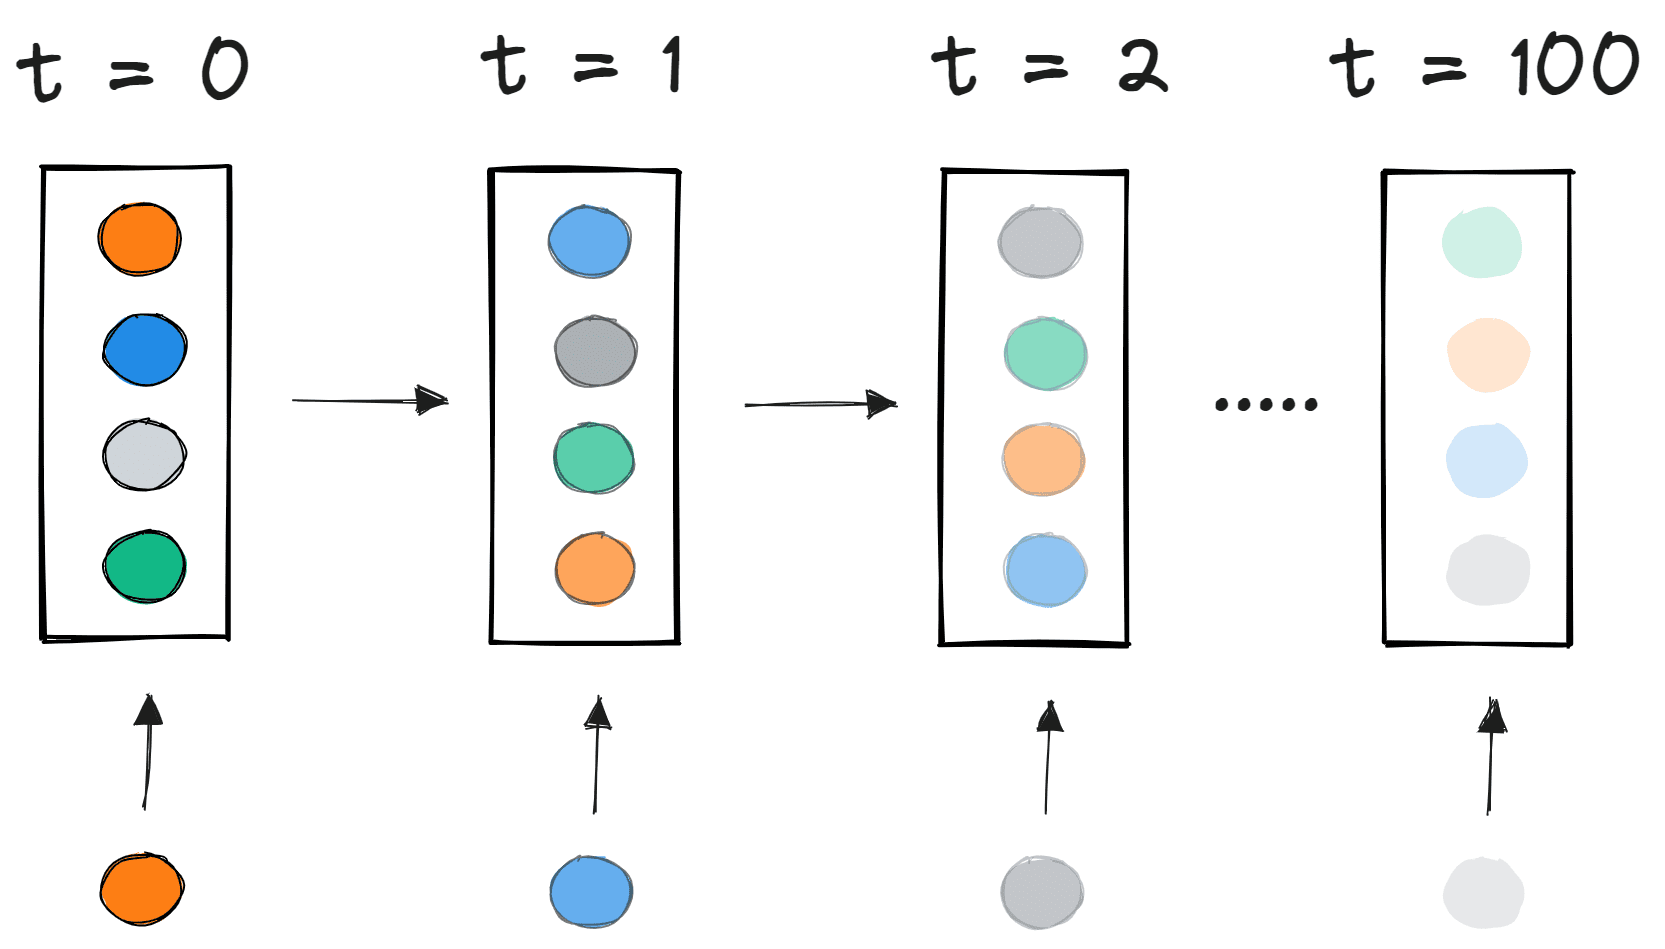

https://medium.com/@El_Fares_Anass/a-basic-explanation-how-the-gradient-descent-is-determined-during-back-propagation-864376f8f1a4

https://www.kdnuggets.com/2022/02/vanishing-gradient-problem.html

https://kharshit.github.io/blog/2019/01/04/the-gradient-problem-in-rnn



In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Generate some toy data
X = np.random.rand(1000, 10, 1)  # 1000 samples, 10 time steps, 1 feature
y = np.random.randint(0, 2, size=(1000,1))  # Binary classification labels

# Define a custom RNN model
class CustomRNNModel(tf.keras.Model):
    def __init__(self, units, depth):
        super(CustomRNNModel, self).__init__()
        self.depth = depth
        self.rnn_layer = [tf.keras.layers.SimpleRNN(units, return_sequences=False) for _ in range(depth)]
        self.dense_layer = tf.keras.layers.Dense(1, activation='sigmoid')

    def call(self, inputs):
        states = inputs
        for i in range(self.depth):
            states = self.rnn_layer[i](states)
        outputs = self.dense_layer(states[:, -1, :]) # Use the last time step's (layer) output for classification
        return outputs
    
# Create the custom RNN model
units = 10
depth = 5
model_rnn = CustomRNNModel(units, depth)

# Compile the model
model_rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


# Define a function to compute gradients - average gradient magnitude across all layers
def get_gradients(inputs, model):
    with tf.GradientTape(persistent=True) as tape:
        predictions = model(inputs)
        loss = tf.keras.losses.binary_crossentropy(y, predictions)
    gradients = tape.gradient(loss, model.trainable_variables)
    del tape
    return gradients

# Train the model and track gradients
num_epochs = 10
gradients_history = [[] for _ in range(depth)]  # To store gradients for each layer
for epoch in range(num_epochs):
    # Train the model for one epoch
    model_rnn.fit(X, y, epochs=1, batch_size=32, verbose=0)
    
    # Get gradients after the epoch
    gradients = get_gradients(X, model_rnn)
    
    # Store average gradient magnitude for each layer
    for i in range(depth):
        layer_gradients = gradients[i*2:(i+1)*2]  # Get weights and biases for the layer
        avg_gradient_magnitude = np.mean([tf.norm(g).numpy() for g in layer_gradients])
        gradients_history[i].append(avg_gradient_magnitude)
